In [8]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8)
    }
)


# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
AXES_MARGINS = dict(left=0.14, right=0.98, bottom=0.14, top=0.82) # percentages of the figure height/width

plt.rcParams.update(
    {
        "figure.subplot.left": AXES_MARGINS["left"],
        "figure.subplot.right": AXES_MARGINS["right"],
        "figure.subplot.bottom": AXES_MARGINS["bottom"],
        "figure.subplot.top": AXES_MARGINS["top"],
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# apply to figures to apply even if using tight_layout
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)

In [9]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

DATA_DIR = Path("data_t1e-1")
DATA_DIR_SCAN = Path("data_t1e-1")
NCOLS = 4

TAG_WOUTDRES = "wout_scan62_woutDres.nc"  # without Delta_res
TAG_WDRES = "wout_scan60_wDres.nc"  # with Delta_res

# Bmin/Bmax from each DESC equilibrium (sampled |B| on a dense grid).
# These match the linspace endpoints used in trapped_map_Bcrit_scan.py.
EQUILIBRIA = {
    "wDres": {
        "color": "blue",
        "label": r"With $\Delta_{\mathrm{res}}$",
        "suptitle": r"With $\Delta_{\mathrm{res}}$",
        "eq_file": "final_wDres.h5",
        "Bmin": 4.341210916625918,
        "Bmax": 6.216886611523893,
    },
    "woutDres": {
        "color": "tab:red",
        "label": r"Without $\Delta_{\mathrm{res}}$",
        "suptitle": r"Without $\Delta_{\mathrm{res}}$",
        "eq_file": "final_woutDres.h5",
        "Bmin": 4.2285330606138904,
        "Bmax": 6.520143658039794,
    },
    TAG_WDRES: {
        "color": "blue",
        "label": r"With $\Delta_{\mathrm{res}}$",
        "suptitle": r"With $\Delta_{\mathrm{res}}$",
        "eq_file": "wout_scan60_wDres.nc",
        "Bmin": 4.341210916625918,
        "Bmax": 6.216886611523893,
    },
    TAG_WOUTDRES: {
        "color": "tab:red",
        "label": r"Without $\Delta_{\mathrm{res}}$",
        "suptitle": r"Without $\Delta_{\mathrm{res}}$",
        "eq_file": "wout_scan62_woutDres.nc",
        "Bmin": 4.2285330606138904,
        "Bmax": 6.520143658039794,
    },
}


def normalize_bcrit(bcrit: float, Bmin: float, Bmax: float) -> float:
    """Map Bcrit onto the loss-fraction scan axis: (Bcrit - Bmin)/(Bmax - Bmin)."""
    return (bcrit - Bmin) / (Bmax - Bmin)


def list_poincare_files(tag: str, data_dir: Path = DATA_DIR):
    """Return (Bcrit, path) pairs sorted by Bcrit for a given equilibrium tag."""
    pattern = re.compile(rf"trapped_map_{re.escape(tag)}_Bcrit_(.+)\.npz$")
    files = []
    for path in data_dir.glob(f"trapped_map_{tag}_Bcrit_*.npz"):
        match = pattern.match(path.name)
        if match is None:
            continue
        files.append((float(match.group(1)), path))
    return sorted(files, key=lambda item: item[0])


def list_frequency_files(tag: str, data_dir: Path = DATA_DIR, perfect: bool = False):
    """Return (Bcrit, path) pairs for frequency profiles, sorted by Bcrit."""
    prefix = "frequencies_perfect" if perfect else "frequencies"
    pattern = re.compile(rf"{re.escape(prefix)}_{re.escape(tag)}_Bcrit_(.+)\.npz$")
    files = []
    for path in data_dir.glob(f"{prefix}_{tag}_Bcrit_*.npz"):
        match = pattern.match(path.name)
        if match is None:
            continue
        files.append((float(match.group(1)), path))
    return sorted(files, key=lambda item: item[0])


def files_by_normalized_bcrit(tag: str, data_dir: Path = DATA_DIR):
    """Return {normalized Bcrit: (Bcrit, path)} for one equilibrium tag."""
    meta = EQUILIBRIA[tag]
    Bmin, Bmax = meta["Bmin"], meta["Bmax"]
    out = {}
    for bcrit, path in list_poincare_files(tag, data_dir=data_dir):
        xbar = normalize_bcrit(bcrit, Bmin, Bmax)
        out[round(xbar, 6)] = (bcrit, path)
    return out


def frequency_path_for(poincare_path: Path) -> Path:
    """Map trapped_map_*.npz -> frequencies_*.npz in the same directory."""
    return poincare_path.with_name(
        poincare_path.name.replace("trapped_map_", "frequencies_", 1)
    )


def plot_poincare_ax(ax, etas_all, s_all, color):
    """Reproduce TrappedPoincare.plot_poincare styling on a given axis."""
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$s$")
    ax.set_xlim([0, 2 * np.pi])
    ax.set_ylim([0, 1])
    for etas, svals in zip(etas_all, s_all):
        if len(etas) == 0:
            continue
        ax.scatter(
            np.mod(etas, 2 * np.pi),
            svals,
            marker="o",
            s=0.1,
            edgecolors="none",
            c=color,
            rasterized=True
        )


def plot_frequency_ax(
    ax,
    s_prof,
    omega_eta_prof,
    omega_b_prof,
    color,
    label=None,
    lw=1.5,
    alpha=1.0,
    zorder=2,
    omit=False
):
    """Plot s vs Omega_eta = omega_eta/omega_b with s on the vertical axis."""
    ax.set_xlabel(r"$\Omega_\eta", **label_kw)
    ax.set_ylabel(r"$s$", **label_kw)
    ax.set_ylim([0, 1])
    if len(s_prof) == 0:
        return None
    ratio = np.asarray(omega_eta_prof) / np.asarray(omega_b_prof)
    if omit:
        ratio = ratio[3:]
        s_prof = s_prof[3:]
    return ax.plot(
        ratio,
        s_prof,
        color=color,
        lw=lw,
        alpha=alpha,
        label=label,
        zorder=zorder,
    )[0]


def add_rational_omega_eta_lines(
    ax,
    q_max: int = 5,
    x_max=None,
    x_min=None,
    rotation=90,
    label_stride: int = 1,
    label_x_offsets=None,
    omit_labels=None,
):
    """Draw vertical dotted lines at rational Omega_eta = +/- p/q up to order q_max.

    All matching resonances get a line. Labels can be thinned with label_stride
    (every other, etc.), always keeping the zero resonance labeled when present.
    label_x_offsets maps resonance value -> horizontal data-coordinate nudge for
    that label only. omit_labels is a set/list of resonance values to leave unlabeled.
    """
    if x_max is None:
        x_max = ax.get_xlim()[1]
    if x_min is None:
        x_min = ax.get_xlim()[0]
    if label_x_offsets is None:
        label_x_offsets = {}
    if omit_labels is None:
        omit_labels = set()
    else:
        omit_labels = {round(v, 8) for v in omit_labels}

    items = []
    drawn = set()
    for q in range(1, q_max + 1):
        for p in range(0, q + 1):
            # Include the equivalent negative resonance -p/q (0 only once).
            signs = (1,) if p == 0 else (1, -1)
            for sign in signs:
                val = sign * p / q
                if val < x_min - 1e-12 or val > x_max + 1e-12:
                    continue
                key = round(val, 8)
                if key in drawn:
                    continue
                drawn.add(key)
                label = rf"$0$" if p == 0 else (rf"$-{p}/{q}$" if sign < 0 else rf"${p}/{q}$")
                items.append((val, label))

    items.sort(key=lambda item: item[0])
    for val, _ in items:
        ax.axvline(val, color="0.55", ls=":", lw=0.9, zorder=0)

    if label_stride <= 1:
        to_label = items
    else:
        zero_idx = next(
            (i for i, (val, _) in enumerate(items) if abs(val) < 1e-12),
            None,
        )
        if zero_idx is None:
            # Fall back to labeling even indices if 0 is outside the window.
            to_label = items[::label_stride]
        else:
            to_label = [
                item
                for i, item in enumerate(items)
                if (i - zero_idx) % label_stride == 0
            ]

    for val, label in to_label:
        if round(val, 8) in omit_labels:
            continue
        dx = label_x_offsets.get(round(val, 8), label_x_offsets.get(val, 0.0))
        ax.text(
            val + dx,
            1.02,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=tick_labelsize,
            rotation=rotation,
            clip_on=False,
        )


def plot_equilibrium_grid(tag: str, data_dir: Path = DATA_DIR):
    """Plot all Bcrit Poincare maps for one equilibrium in a 4-column grid."""
    meta = EQUILIBRIA[tag]
    files = list_poincare_files(tag, data_dir=data_dir)
    if not files:
        raise FileNotFoundError(
            f"No Poincare .npz files found for tag={tag!r} in {data_dir}"
        )

    Bmin, Bmax = meta["Bmin"], meta["Bmax"]
    nplots = len(files)
    nrows = int(np.ceil(nplots / NCOLS))
    fig, axes = plt.subplots(
        nrows,
        NCOLS,
        figsize=(4 * NCOLS, 3.2 * nrows),
        squeeze=False,
        constrained_layout=True,
    )

    for i, (bcrit, path) in enumerate(files):
        ax = axes[i // NCOLS, i % NCOLS]
        data = np.load(path, allow_pickle=True)
        plot_poincare_ax(ax, data["etas_all"], data["s_all"], meta["color"])
        x = normalize_bcrit(bcrit, Bmin, Bmax)
        ax.set_title(
            rf"$\dfrac{{B_{{\mathrm{{crit}}}} - B_{{\mathrm{{min}}}}}}"
            rf"{{B_{{\mathrm{{max}}}} - B_{{\mathrm{{min}}}}}} = {x:.3f}$"
        )

    for j in range(nplots, nrows * NCOLS):
        axes[j // NCOLS, j % NCOLS].axis("off")

    fig.suptitle(meta["suptitle"], fontsize=16)
    return fig, axes


def _load_and_plot_freq(ax, freq_path, color, lw, alpha, zorder):
    """Load a frequencies_*.npz file and plot Omega_eta(s)."""
    if freq_path is None or not Path(freq_path).exists():
        return
    freq = np.load(freq_path)
    omit = False
    omit1 = 'data_32scan_updated/frequencies_perfect_wout_scan62_woutDres.nc_Bcrit_5.554.npz'
    omit2 = 'data_32scan_updated/frequencies_perfect_wout_scan60_wDres.nc_Bcrit_5.427.npz'
    if str(freq_path) in {omit1, omit2}:
        omit = True
    plot_frequency_ax(
        ax,
        freq["s_prof"],
        freq["omega_eta_prof"],
        freq["omega_b_prof"],
        color,
        label=None,
        lw=lw,
        alpha=alpha,
        zorder=zorder,
        omit=omit
    )


def plot_bcrit_comparison_row(
    xbar,
    woutdres_path,
    wdres_path,
    woutdres_freq=None,
    wdres_freq=None,
    woutdres_freq_perfect=None,
    wdres_freq_perfect=None,
    q_max=5,
    figsize=(18, 5),
):
    """One figure with 3 columns: woutDres Poincare, wDres Poincare, overlaid Omega_eta.

    Omega_eta panel overlays up to four curves:
      - perfect profiles: thicker lines
      - non-perfect profiles: thinner, alpha=0.3
    Legend has only two entries (one per equilibrium color).
    """
    meta_wout = EQUILIBRIA[TAG_WOUTDRES]
    meta_w = EQUILIBRIA[TAG_WDRES]

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)
    ax_wout, ax_w, ax_f = axes

    if woutdres_path is not None:
        data = np.load(woutdres_path, allow_pickle=True)
        plot_poincare_ax(ax_wout, data["etas_all"], data["s_all"], meta_wout["color"])
    ax_wout.set_title(meta_wout["label"])

    if wdres_path is not None:
        data = np.load(wdres_path, allow_pickle=True)
        plot_poincare_ax(ax_w, data["etas_all"], data["s_all"], meta_w["color"])
    ax_w.set_title(meta_w["label"])

    # Fall back to frequencies_*.npz next to the Poincare file if not passed.
    if woutdres_freq is None and woutdres_path is not None:
        woutdres_freq = frequency_path_for(woutdres_path)
    if wdres_freq is None and wdres_path is not None:
        wdres_freq = frequency_path_for(wdres_path)

    # Non-perfect first (faint background), then perfect (prominent).
    _load_and_plot_freq(ax_f, woutdres_freq, meta_wout["color"], lw=1.0, alpha=0.3, zorder=1)
    _load_and_plot_freq(ax_f, wdres_freq, meta_w["color"], lw=1.0, alpha=0.3, zorder=1)
    _load_and_plot_freq(
        ax_f, woutdres_freq_perfect, meta_wout["color"], lw=2.0, alpha=1.0, zorder=3
    )
    _load_and_plot_freq(
        ax_f, wdres_freq_perfect, meta_w["color"], lw=2.0, alpha=1.0, zorder=3
    )

    legend_handles = [
        Line2D([0], [0], color=meta_wout["color"], lw=2.0, label=meta_wout["label"]),
        Line2D([0], [0], color=meta_w["color"], lw=2.0, label=meta_w["label"]),
    ]
    ax_f.legend(handles=legend_handles, loc="best", fontsize=10)

    add_rational_omega_eta_lines(ax_f, q_max=q_max)
    ax_f.set_title(r"$\Omega_\eta$ profiles")

    fig.suptitle(rf"$\overline{{B_{{\mathrm{{crit}}}}}} = {xbar:.3f}$", fontsize=16)
    return fig, axes


def bcrit_stem(bcrit_wout=None, bcrit_w=None):
    """Filename stem naming the absolute Bcrit used by each equilibrium."""
    parts = []
    if bcrit_wout is not None:
        parts.append(f"woutDres_{bcrit_wout:.4f}")
    if bcrit_w is not None:
        parts.append(f"wDres_{bcrit_w:.4f}")
    return "Bcrit_" + "_".join(parts)


def plot_bcrit_comparison_scan(data_dir=DATA_DIR_SCAN, q_max=7):
    """One figure per normalized Bcrit with side-by-side Poincare and Omega_eta overlay.

    Perfect and non-perfect frequency files use different absolute Bcrit grids
    (different |B| ranges), so they are paired by scan index within each tag.
    """
    by_wout = files_by_normalized_bcrit(TAG_WOUTDRES, data_dir=data_dir)
    by_w = files_by_normalized_bcrit(TAG_WDRES, data_dir=data_dir)
    xbars = sorted(set(by_wout) | set(by_w))

    # Sorted frequency lists; index i pairs with the i-th Poincare / xbar entry.
    poinc_wout = list_poincare_files(TAG_WOUTDRES, data_dir=data_dir)
    poinc_w = list_poincare_files(TAG_WDRES, data_dir=data_dir)
    freq_wout = list_frequency_files(TAG_WOUTDRES, data_dir=data_dir, perfect=False)
    freq_w = list_frequency_files(TAG_WDRES, data_dir=data_dir, perfect=False)
    freq_wout_perf = list_frequency_files(TAG_WOUTDRES, data_dir=data_dir, perfect=True)
    freq_w_perf = list_frequency_files(TAG_WDRES, data_dir=data_dir, perfect=True)

    # Map rounded xbar -> scan index from the Poincare file lists (non-perfect Bcrit grid).
    xbar_to_idx_wout = {
        round(normalize_bcrit(b, EQUILIBRIA[TAG_WOUTDRES]["Bmin"], EQUILIBRIA[TAG_WOUTDRES]["Bmax"]), 6): i
        for i, (b, _) in enumerate(poinc_wout)
    }
    xbar_to_idx_w = {
        round(normalize_bcrit(b, EQUILIBRIA[TAG_WDRES]["Bmin"], EQUILIBRIA[TAG_WDRES]["Bmax"]), 6): i
        for i, (b, _) in enumerate(poinc_w)
    }

    figs = []
    for xbar in xbars:
        bcrit_wout, wout_path = by_wout.get(xbar, (None, None))
        bcrit_w, w_path = by_w.get(xbar, (None, None))
        if wout_path is None and w_path is None:
            continue

        idx_wout = xbar_to_idx_wout.get(xbar)
        idx_w = xbar_to_idx_w.get(xbar)
        # Prefer a shared index when both equilibria have this xbar.
        idx = idx_wout if idx_wout is not None else idx_w

        def pick(freq_list, i):
            if i is None or i >= len(freq_list):
                return None
            return freq_list[i][1]

        fig, _ = plot_bcrit_comparison_row(
            xbar,
            wout_path,
            w_path,
            woutdres_freq=pick(freq_wout, idx_wout if idx_wout is not None else idx),
            wdres_freq=pick(freq_w, idx_w if idx_w is not None else idx),
            woutdres_freq_perfect=pick(freq_wout_perf, idx_wout if idx_wout is not None else idx),
            wdres_freq_perfect=pick(freq_w_perf, idx_w if idx_w is not None else idx),
            q_max=q_max,
        )
        fig.savefig(f'figures_t3e-1/{bcrit_stem(bcrit_wout, bcrit_w)}_compare.png')
        figs.append(fig)
    return figs


Generated 8 figures


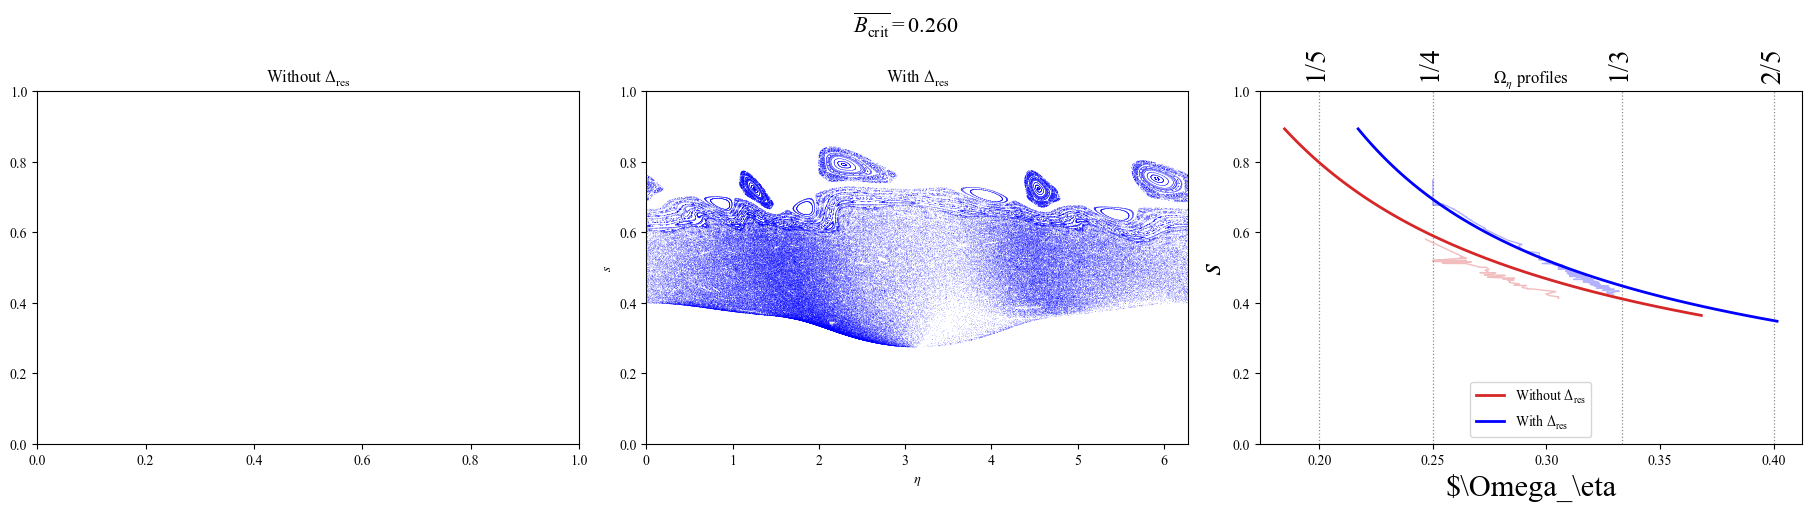

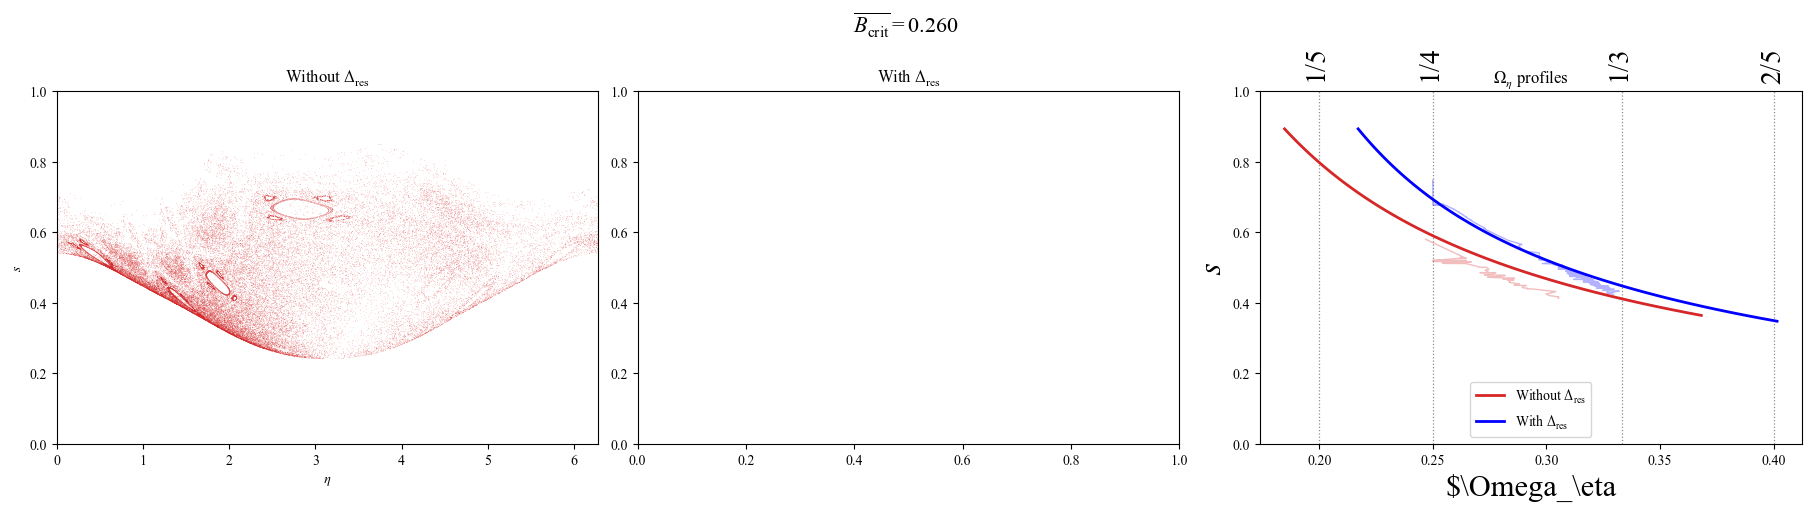

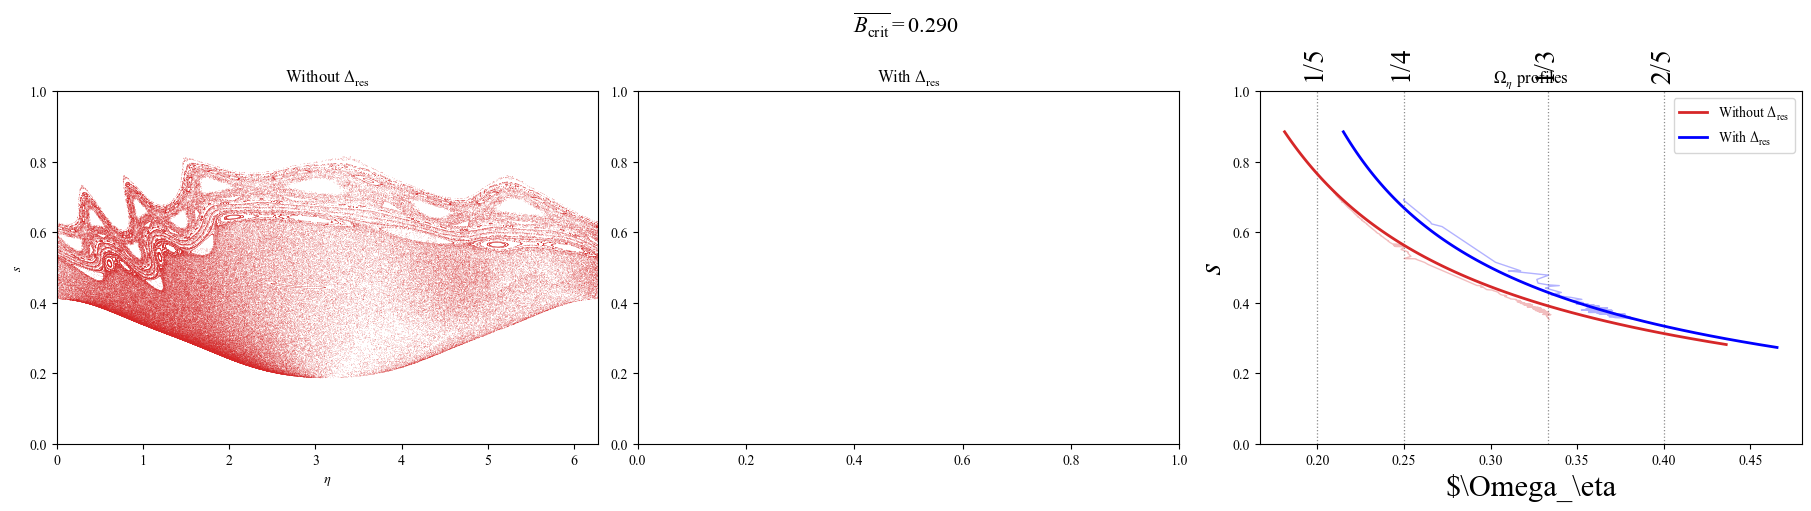

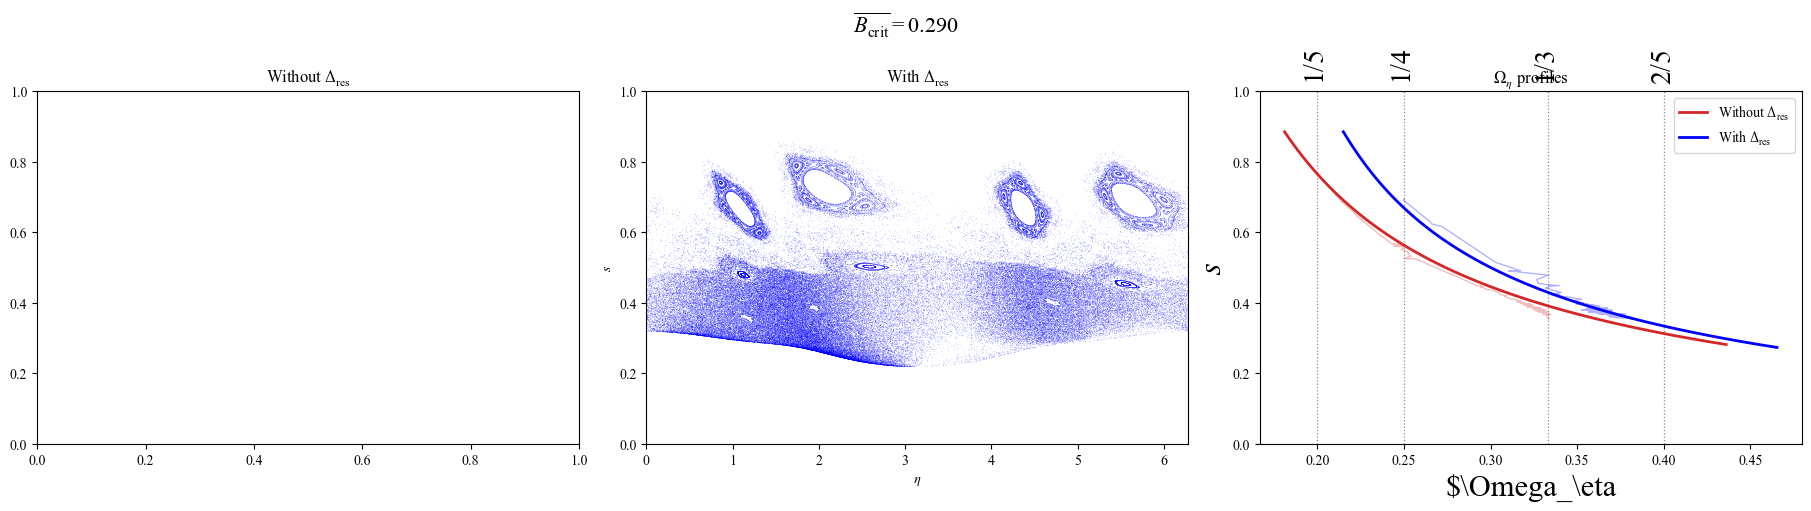

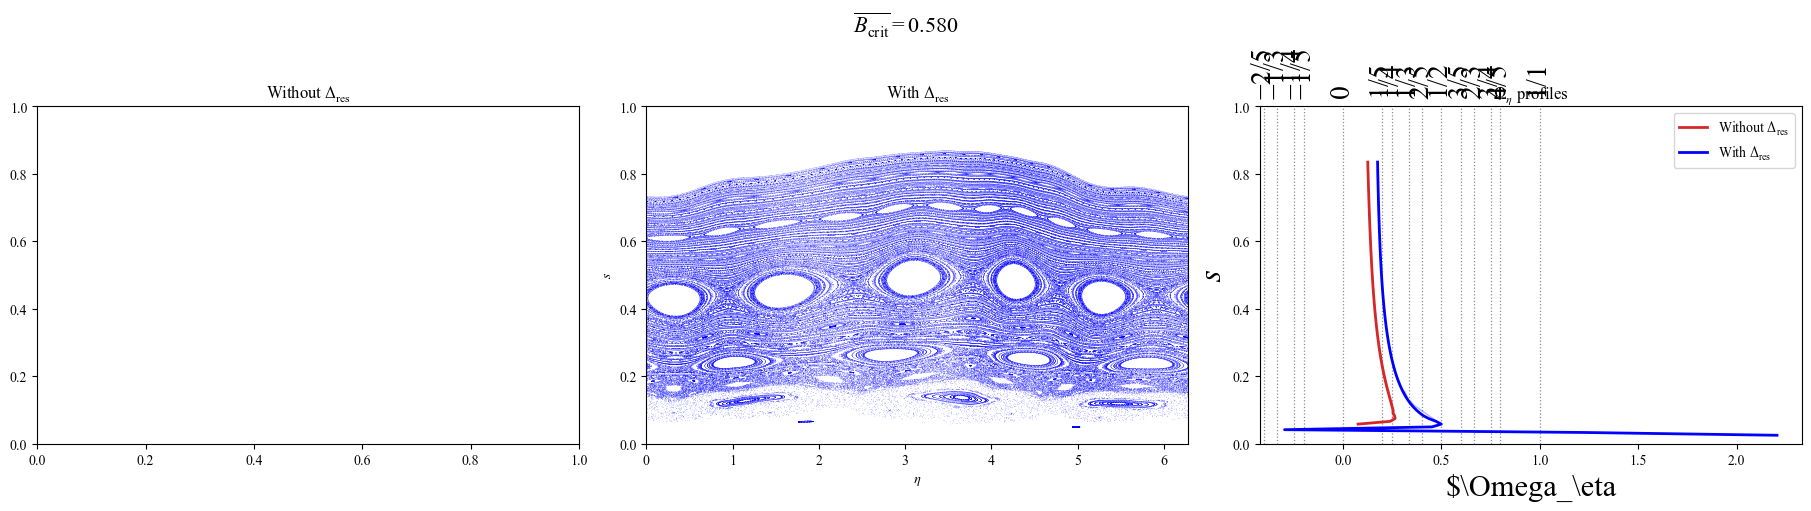

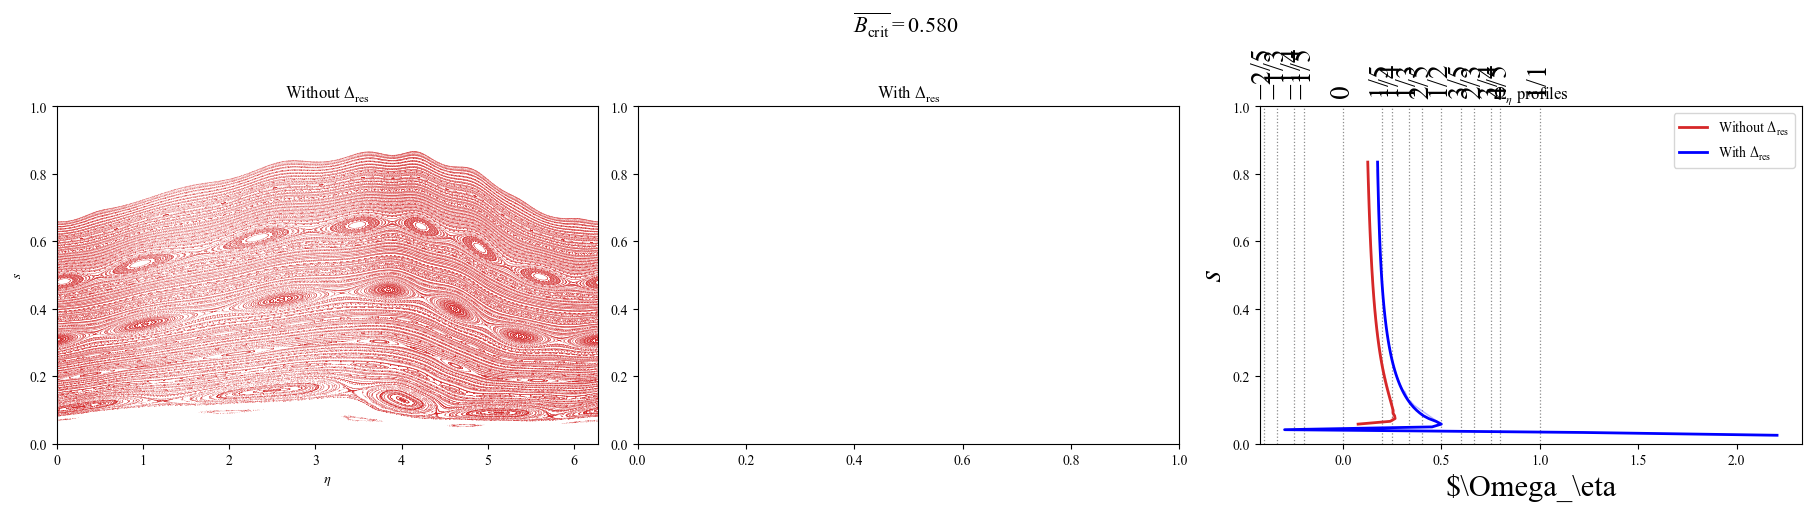

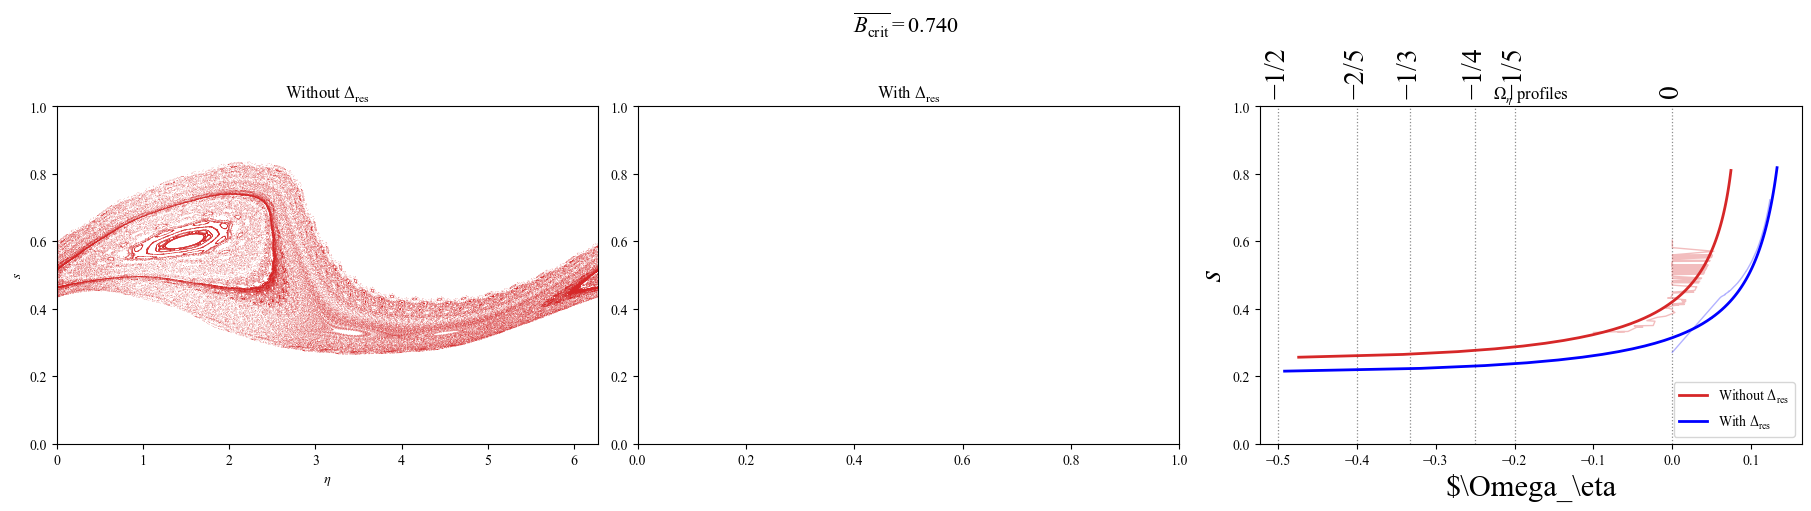

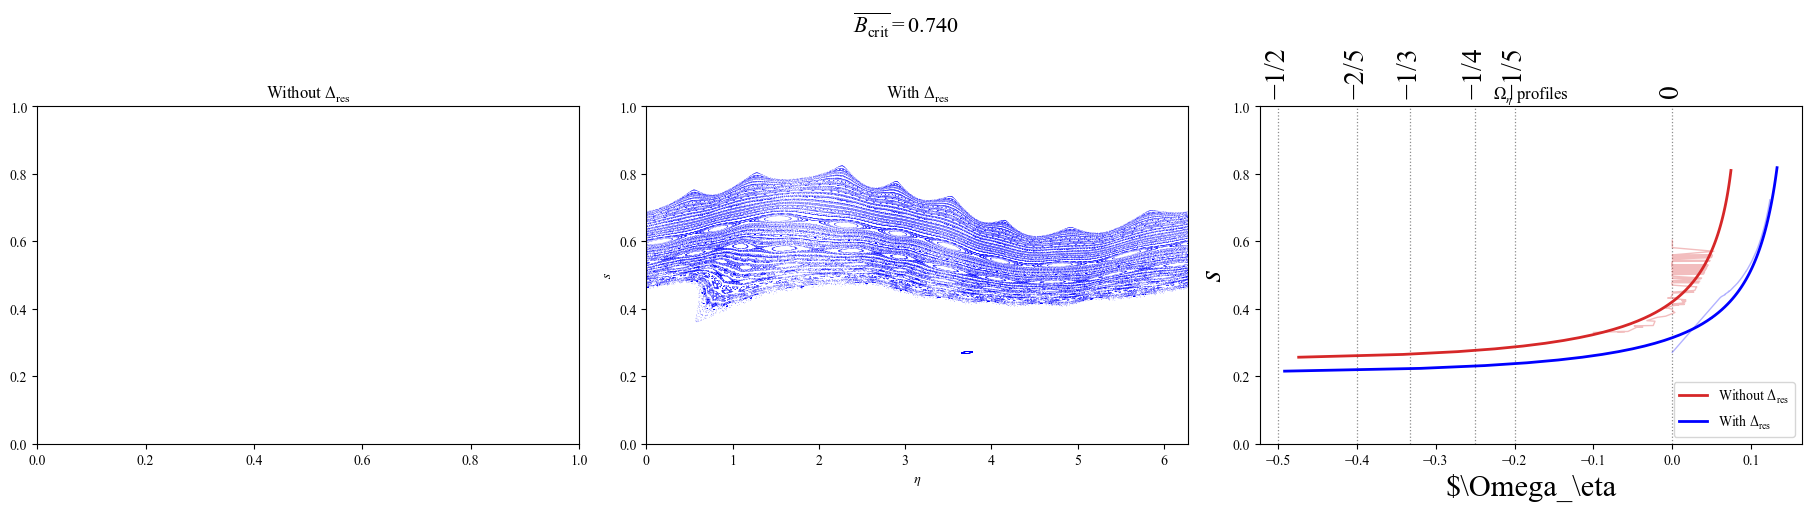

In [10]:
# One figure per normalized Bcrit (32 total):
#   col 1 = woutDres Poincare (red)
#   col 2 = wDres Poincare (blue)
#   col 3 = Omega_eta overlay:
#       thick  = perfect frequencies_perfect_*
#       faint  = non-perfect frequencies_*  (lw smaller, alpha=0.3)
#       legend = two color entries only
# Re-run cell 0 first if you get NameError.
figs = plot_bcrit_comparison_scan(data_dir=DATA_DIR_SCAN, q_max=5)
print(f"Generated {len(figs)} figures")
for fig in figs:
    plt.show()
    plt.close(fig)


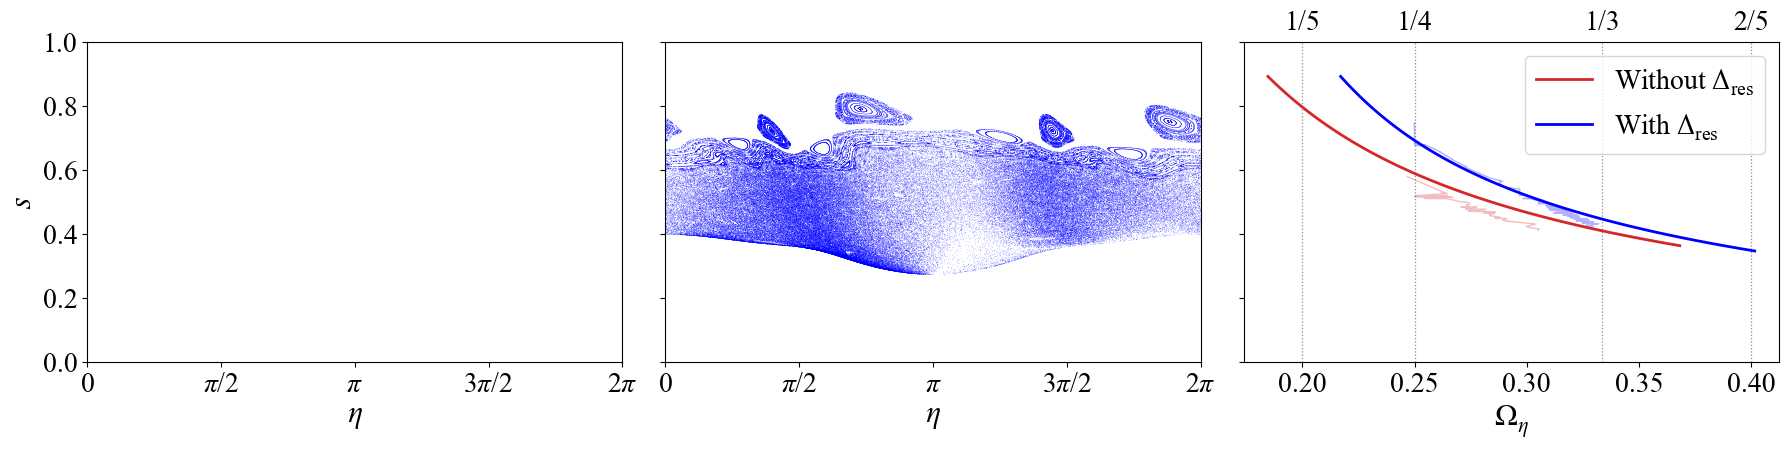

Saved figures_t3e-1/Bcrit_wDres_4.8289_compare.pdf (scan xbar=0.260007)


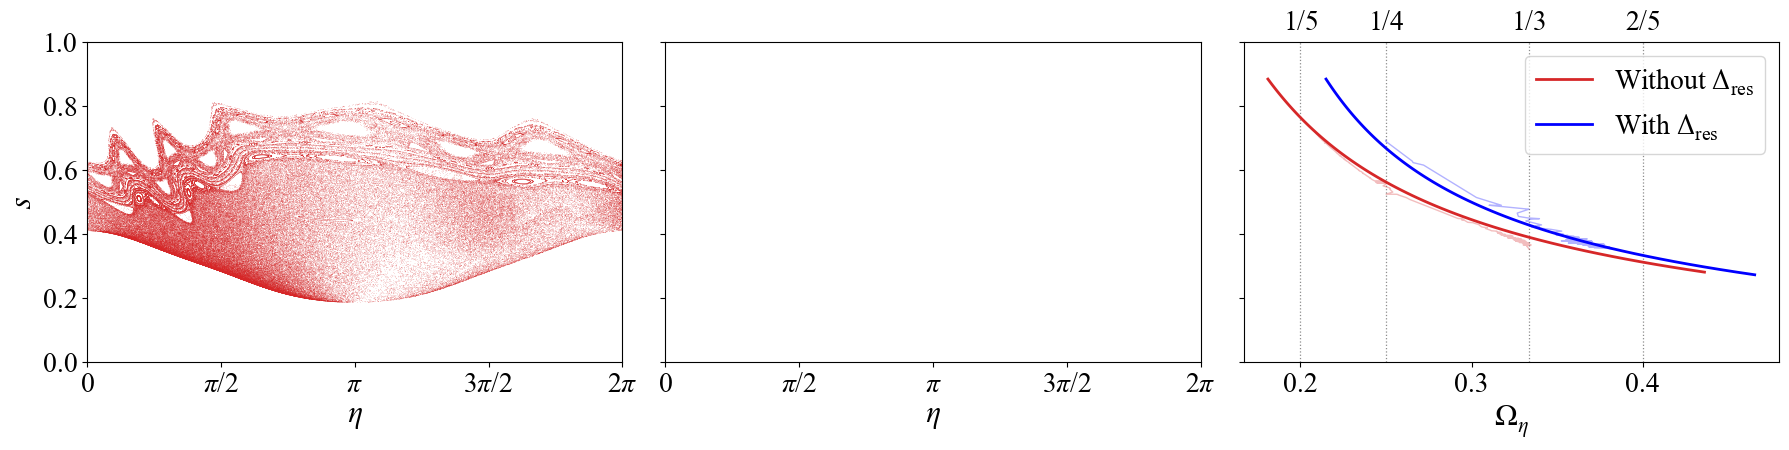

Saved figures_t3e-1/Bcrit_woutDres_4.8931_compare.pdf (scan xbar=0.29)


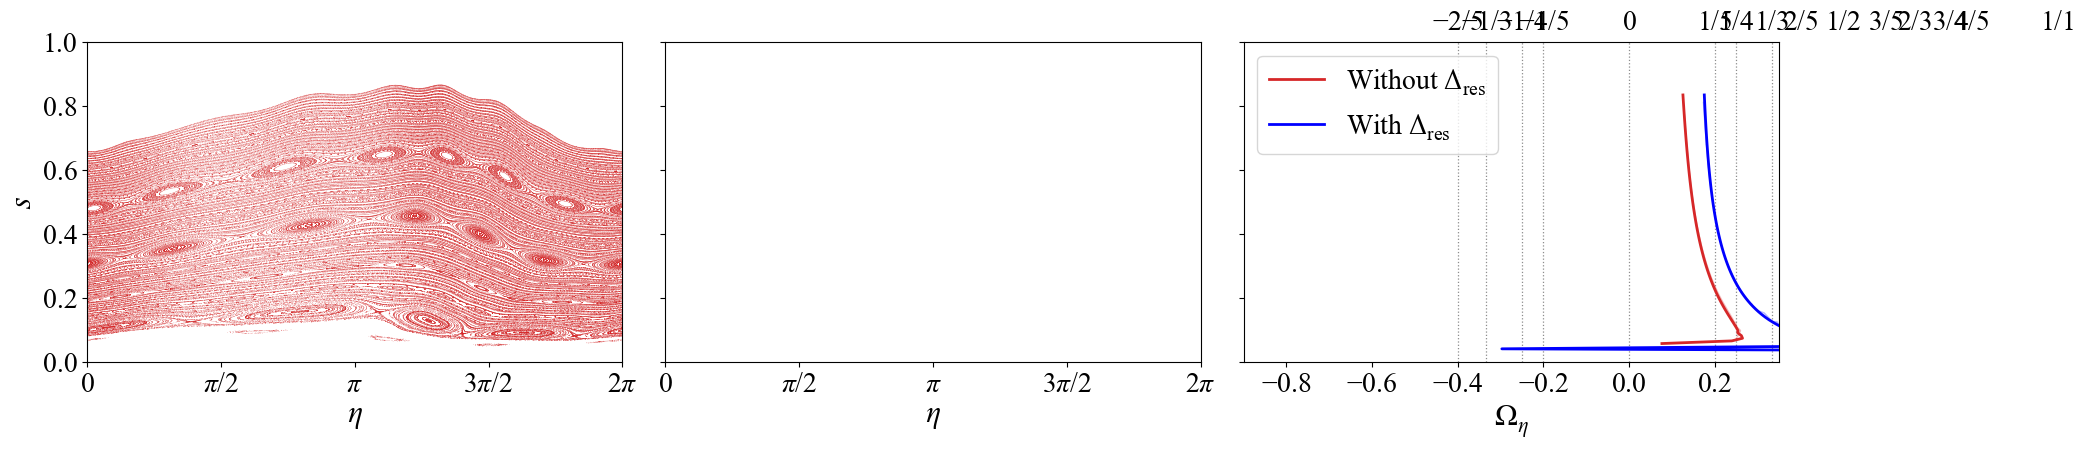

Saved figures_t3e-1/Bcrit_woutDres_5.5577_compare.pdf (scan xbar=0.580014)


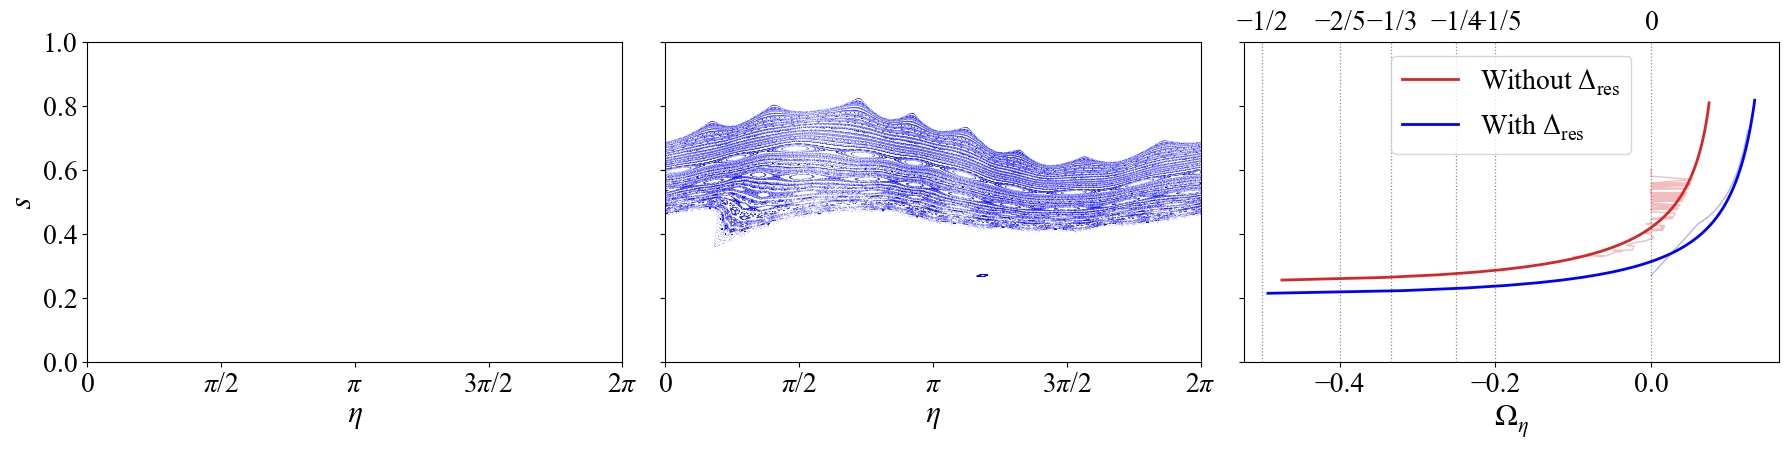

Saved figures_t3e-1/Bcrit_wDres_5.7292_compare.pdf (scan xbar=0.739994)
Wrote 4 PDFs


In [11]:
# Save four selected Bcrit comparison figures as PDFs with publication styling.
# Re-run cells 0 and 1 first if you get NameError.

XBARS_PDF = [0.258, 0.290, 0.581, 0.742]
OUT_DIR = Path("figures_t3e-1")
OUT_DIR.mkdir(exist_ok=True)

ETA_TICKS = [0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi]
ETA_TICKLABELS = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
OMEGA_XLIM_SPECIAL = {0.580645: (-1.0, 0.4)}

# Identical figure canvas and equal axes boxes for every PDF (figure coordinates).
FIGSIZE_PDF = (18.0, 5.0)
EQUAL_AXES_LAYOUT = dict(left=0.055, right=0.995, bottom=0.18, top=0.82, wspace=0.08)


def apply_equal_axes_layout(
    fig,
    axes,
    left=EQUAL_AXES_LAYOUT["left"],
    right=EQUAL_AXES_LAYOUT["right"],
    bottom=EQUAL_AXES_LAYOUT["bottom"],
    top=EQUAL_AXES_LAYOUT["top"],
    wspace=EQUAL_AXES_LAYOUT["wspace"],
):
    """Force three equal-size axes; same geometry on every figure with FIGSIZE_PDF."""
    fig.set_size_inches(*FIGSIZE_PDF)
    # Disable engines that resize axes based on tick/legend content.
    try:
        fig.set_layout_engine(None)
    except Exception:
        fig.set_constrained_layout(False)

    n = len(axes)
    usable = right - left
    # Matplotlib wspace convention: gap = wspace * average-axes-width.
    width = usable / (n + (n - 1) * wspace)
    height = top - bottom
    gap = width * wspace
    for i, ax in enumerate(axes):
        x0 = left + i * (width + gap)
        ax.set_position([x0, bottom, width, height])


def _closest_xbar(wanted, available):
    return min(available, key=lambda x: abs(x - wanted))


def _clear_rational_omega_eta_artists(ax):
    """Remove dotted resonance lines and their fraction labels."""
    for line in list(ax.lines):
        if line.get_linestyle() == ":":
            line.remove()
    for text in list(ax.texts):
        text.remove()


def style_bcrit_comparison_for_pdf(fig, axes, xbar=None, q_max=5):
    """Strip titles; hide middle/right y labels; pi ticks on Poincare panels; upright rationals."""
    fig.suptitle("")
    ax_wout, ax_w, ax_f = axes
    for ax in axes:
        ax.set_title("")

    # Middle and right: keep y tick marks, drop axis label and tick labels.
    ax_wout.set_ylabel(r"$s$", **label_kw)
    for ax in (ax_w, ax_f):
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)

    # Left and middle Poincare panels share the eta axis.
    for ax in (ax_wout, ax_w):
        ax.set_xticks(ETA_TICKS)
        ax.set_xticklabels(ETA_TICKLABELS)
        ax.set_xlabel(r"$\eta$", **label_kw)

    ax_f.set_xlabel(r"$\Omega_\eta$", **label_kw)

    # Special Omega_eta window for one scan point (includes negative resonances).
    if xbar is not None:
        for key, lims in OMEGA_XLIM_SPECIAL.items():
            if abs(xbar - key) < 1e-4:
                ax_f.set_xlim(*lims)
                break

    # Redraw rationals for the final xlim, including equivalent negatives.
    _clear_rational_omega_eta_artists(ax_f)
    label_stride = 1
    label_x_offsets = None
    omit_labels = None
    if xbar is not None and abs(xbar - 0.580645) < 1e-4:
        # Keep every resonance line; label every other, anchored so 0 remains.
        # Drop 2/5 and -1/1 so edge labels do not hang past the panel.
        label_stride = 2
        omit_labels = {-1, 2 / 5}
    if xbar is not None and abs(xbar - 0.741935) < 1e-4:
        # Nudge -1/5 right so it does not collide with -1/4.
        label_x_offsets = {-1 / 5: 0.02}
    add_rational_omega_eta_lines(
        ax_f,
        q_max=q_max,
        rotation=0,
        label_stride=label_stride,
        label_x_offsets=label_x_offsets,
        omit_labels=omit_labels,
    )

    meta_wout = EQUILIBRIA[TAG_WOUTDRES]
    meta_w = EQUILIBRIA[TAG_WDRES]
    legend_handles = [
        Line2D([0], [0], color=meta_wout["color"], lw=2.0, label=meta_wout["label"]),
        Line2D([0], [0], color=meta_w["color"], lw=2.0, label=meta_w["label"]),
    ]
    ax_f.legend(
        handles=legend_handles,
        loc="best",
        prop={"family": "Times New Roman", "size": tick_labelsize},
    )

    ax_wout.tick_params(axis="x", labelsize=tick_labelsize)
    ax_w.tick_params(axis="x", labelsize=tick_labelsize)
    ax_f.tick_params(axis="x", labelsize=tick_labelsize)
    ax_wout.tick_params(axis="y", labelsize=tick_labelsize)

    apply_equal_axes_layout(fig, axes)


by_wout = files_by_normalized_bcrit(TAG_WOUTDRES, data_dir=DATA_DIR_SCAN)
by_w = files_by_normalized_bcrit(TAG_WDRES, data_dir=DATA_DIR_SCAN)
available = sorted(set(by_wout) | set(by_w))

poinc_wout = list_poincare_files(TAG_WOUTDRES, data_dir=DATA_DIR_SCAN)
poinc_w = list_poincare_files(TAG_WDRES, data_dir=DATA_DIR_SCAN)
freq_wout = list_frequency_files(TAG_WOUTDRES, data_dir=DATA_DIR_SCAN, perfect=False)
freq_w = list_frequency_files(TAG_WDRES, data_dir=DATA_DIR_SCAN, perfect=False)
freq_wout_perf = list_frequency_files(TAG_WOUTDRES, data_dir=DATA_DIR_SCAN, perfect=True)
freq_w_perf = list_frequency_files(TAG_WDRES, data_dir=DATA_DIR_SCAN, perfect=True)

xbar_to_idx_wout = {
    round(
        normalize_bcrit(b, EQUILIBRIA[TAG_WOUTDRES]["Bmin"], EQUILIBRIA[TAG_WOUTDRES]["Bmax"]),
        6,
    ): i
    for i, (b, _) in enumerate(poinc_wout)
}
xbar_to_idx_w = {
    round(
        normalize_bcrit(b, EQUILIBRIA[TAG_WDRES]["Bmin"], EQUILIBRIA[TAG_WDRES]["Bmax"]),
        6,
    ): i
    for i, (b, _) in enumerate(poinc_w)
}


def _pick(freq_list, i):
    if i is None or i >= len(freq_list):
        return None
    return freq_list[i][1]


saved = []

i=0
for xbar_label in XBARS_PDF:
    xbar = _closest_xbar(xbar_label, available)
    bcrit_wout, wout_path = by_wout.get(xbar, (None, None))
    bcrit_w, w_path = by_w.get(xbar, (None, None))
    if wout_path is None and w_path is None:
        print(f"Skipping {xbar_label}: no data near {xbar}")
        continue

    idx_wout = xbar_to_idx_wout.get(xbar)
    idx_w = xbar_to_idx_w.get(xbar)
    idx = idx_wout if idx_wout is not None else idx_w

    fig, axes = plot_bcrit_comparison_row(
        xbar,
        wout_path,
        w_path,
        woutdres_freq=_pick(freq_wout, idx_wout if idx_wout is not None else idx),
        wdres_freq=_pick(freq_w, idx_w if idx_w is not None else idx),
        woutdres_freq_perfect=_pick(
            freq_wout_perf, idx_wout if idx_wout is not None else idx
        ),
        wdres_freq_perfect=_pick(freq_w_perf, idx_w if idx_w is not None else idx),
        q_max=5,
    )

    style_bcrit_comparison_for_pdf(fig, axes, xbar=xbar, q_max=5)

    out_path = OUT_DIR / f"{bcrit_stem(bcrit_wout, bcrit_w)}_compare.pdf"

    if i==2:
        axes[2].set_xlim(-0.9, 0.35)
        # Drop the lowest-s endpoint from the blue (with Delta_res) curves.
        blue = EQUILIBRIA[TAG_WDRES]["color"]
        for line in axes[2].lines:
            if line.get_linestyle() == ":" or line.get_color() != blue:
                continue
            x, y = line.get_data()
            if len(y) == 0:
                continue
            j = int(np.argmin(y))
            mask = np.ones(len(y), dtype=bool)
            mask[j] = False
            line.set_data(x[mask], y[mask])
        axes[2].set_xticks([-0.8, -0.6, -0.4, -0.2, 0, 0.2])
        axes[2].set_xticklabels([r'$-0.8$', r'$-0.6$', r'$-0.4$', r'$-0.2$', r'$0.0$', r'$0.2$'])
    
    apply_equal_axes_layout(fig, axes)
    fig.savefig(out_path)
    saved.append(out_path)
    plt.show()
    plt.close(fig)
    print(f"Saved {out_path} (scan xbar={xbar})")
    i+=1

print(f"Wrote {len(saved)} PDFs")


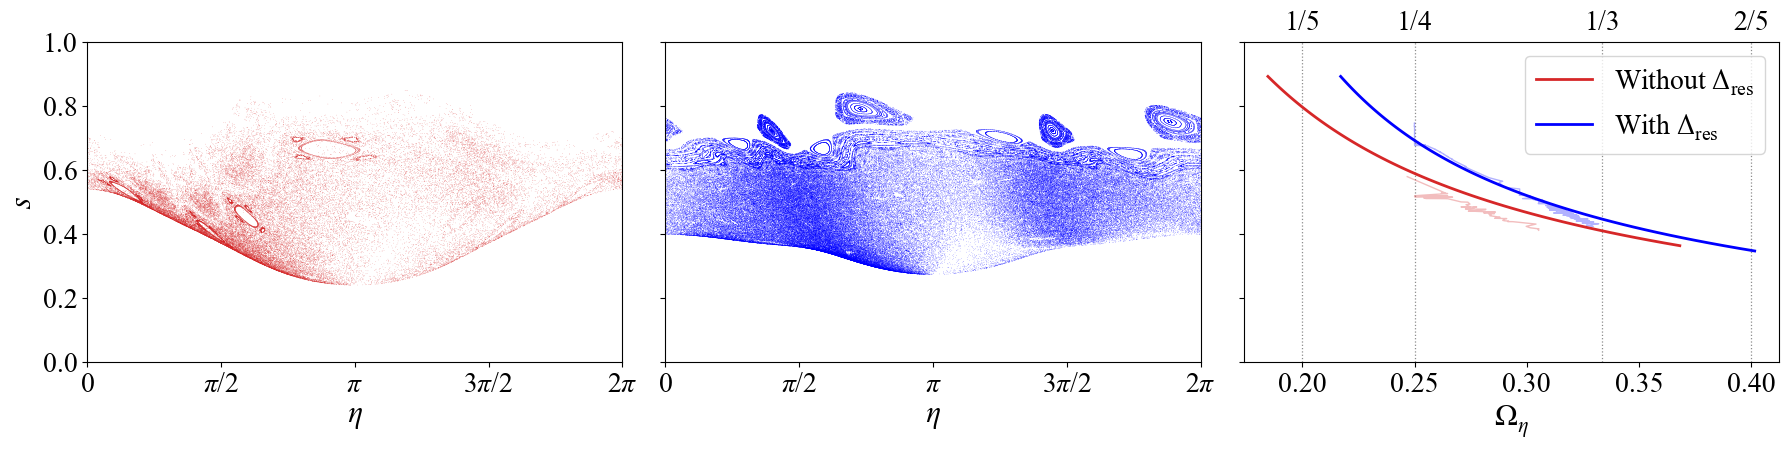

Saved figures_t1e-1/Bcrit_woutDres_4.8244_wDres_4.8289_compare.pdf (label=0.265625, wout=0.260021, wDres=0.260007)


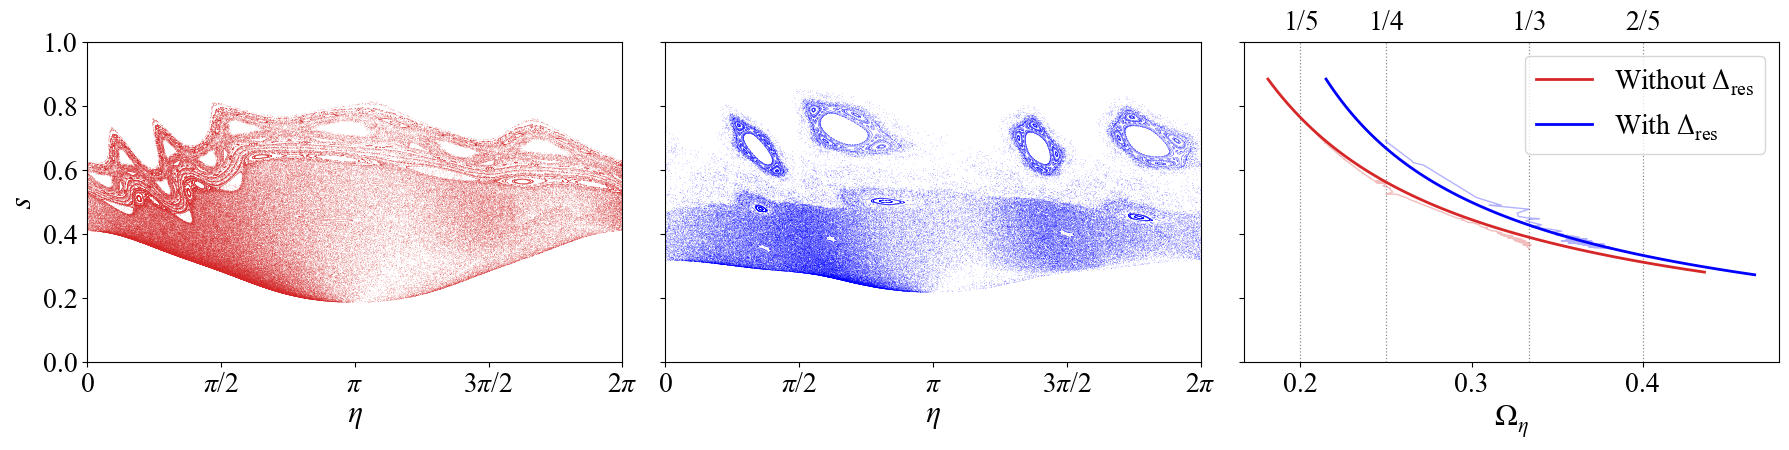

Saved figures_t1e-1/Bcrit_woutDres_4.8931_wDres_4.8852_compare.pdf (label=0.296875, wout=0.29, wDres=0.290023)


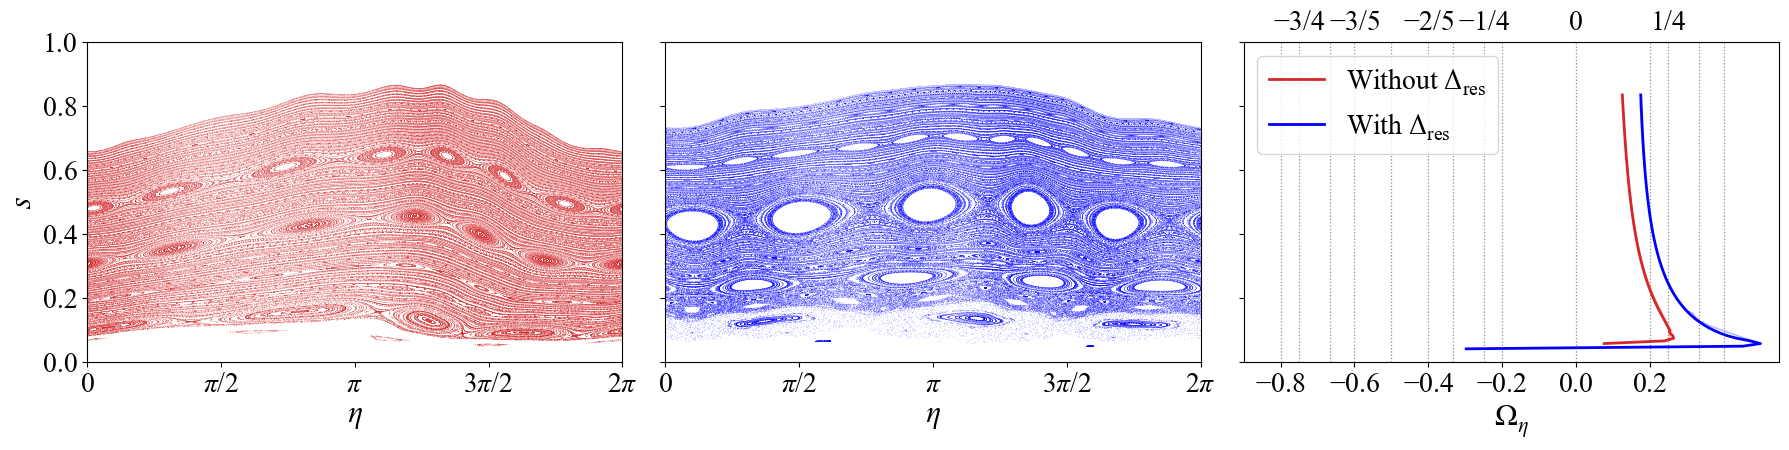

Saved figures_t1e-1/Bcrit_woutDres_5.5577_wDres_5.4291_compare.pdf (label=0.578125, wout=0.580014, wDres=0.579998)


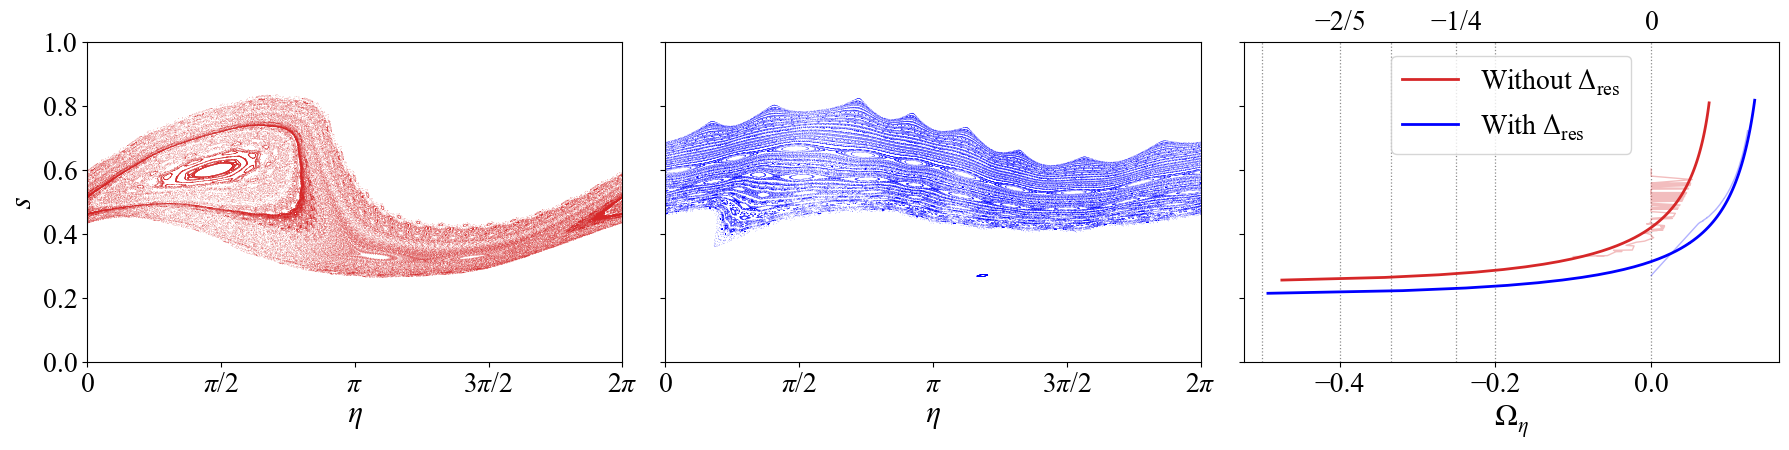

Saved figures_t1e-1/Bcrit_woutDres_5.9243_wDres_5.7292_compare.pdf (label=0.734375, wout=0.739989, wDres=0.739994)
Wrote 4 PDFs


In [16]:
# Save four selected Bcrit comparison figures as PDFs with publication styling.
# Re-run cells 0 and 1 first if you get NameError.

XBARS_PDF = [0.265625, 0.296875, 0.578125, 0.734375]
DATA_DIR_PDF = Path("data_t1e-1")
OUT_DIR = Path("figures_t1e-1")
OUT_DIR.mkdir(exist_ok=True)

ETA_TICKS = [0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi]
ETA_TICKLABELS = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
# Special Omega_eta window keyed by requested XBARS_PDF labels.
OMEGA_XLIM_SPECIAL = {0.578125: (-1.0, 0.4)}
# How many lowest-s points to drop from the thick with-Delta_res (blue)
# Omega_eta curve, keyed by XBARS_PDF label. Near the axis the frequency
# extraction breaks down and those points draw an unphysical excursion.
DROP_LOWEST_S_WDRES = {0.578125: 2}

# Identical figure canvas and equal axes boxes for every PDF (figure coordinates).
FIGSIZE_PDF = (18.0, 5.0)
EQUAL_AXES_LAYOUT = dict(left=0.055, right=0.995, bottom=0.18, top=0.82, wspace=0.08)


def apply_equal_axes_layout(
    fig,
    axes,
    left=EQUAL_AXES_LAYOUT["left"],
    right=EQUAL_AXES_LAYOUT["right"],
    bottom=EQUAL_AXES_LAYOUT["bottom"],
    top=EQUAL_AXES_LAYOUT["top"],
    wspace=EQUAL_AXES_LAYOUT["wspace"],
):
    """Force three equal-size axes; same geometry on every figure with FIGSIZE_PDF."""
    fig.set_size_inches(*FIGSIZE_PDF)
    # Disable engines that resize axes based on tick/legend content.
    try:
        fig.set_layout_engine(None)
    except Exception:
        fig.set_constrained_layout(False)

    n = len(axes)
    usable = right - left
    # Matplotlib wspace convention: gap = wspace * average-axes-width.
    width = usable / (n + (n - 1) * wspace)
    height = top - bottom
    gap = width * wspace
    for i, ax in enumerate(axes):
        x0 = left + i * (width + gap)
        ax.set_position([x0, bottom, width, height])


def _closest_xbar(wanted, available):
    return min(available, key=lambda x: abs(x - wanted))


def drop_lowest_s_wdres(ax, n_drop):
    """Drop the n_drop lowest-s points from the thick with-Delta_res curve.

    Only the perfect profile (alpha=1) is touched; the faint non-perfect
    curves and both without-Delta_res curves are left as-is.
    """
    blue = EQUILIBRIA[TAG_WDRES]["color"]
    for line in ax.lines:
        if line.get_linestyle() == ":" or line.get_color() != blue:
            continue
        if (line.get_alpha() or 1.0) < 0.9:  # faint non-perfect profile
            continue
        x, y = np.asarray(line.get_xdata()), np.asarray(line.get_ydata())
        if len(y) <= n_drop:
            continue
        keep = np.ones(len(y), dtype=bool)
        keep[np.argsort(y)[:n_drop]] = False
        line.set_data(x[keep], y[keep])


def _clear_rational_omega_eta_artists(ax):
    """Remove dotted resonance lines and their fraction labels."""
    for line in list(ax.lines):
        if line.get_linestyle() == ":":
            line.remove()
    for text in list(ax.texts):
        text.remove()


def style_bcrit_comparison_for_pdf(fig, axes, xbar=None, xbar_label=None, q_max=5):
    """Strip titles; hide middle/right y labels; pi ticks on Poincare panels; upright rationals."""
    fig.suptitle("")
    ax_wout, ax_w, ax_f = axes
    for ax in axes:
        ax.set_title("")

    # Middle and right: keep y tick marks, drop axis label and tick labels.
    ax_wout.set_ylabel(r"$s$", **label_kw)
    for ax in (ax_w, ax_f):
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)

    # Left and middle Poincare panels share the eta axis.
    for ax in (ax_wout, ax_w):
        ax.set_xticks(ETA_TICKS)
        ax.set_xticklabels(ETA_TICKLABELS)
        ax.set_xlabel(r"$\eta$", **label_kw)

    ax_f.set_xlabel(r"$\Omega_\eta$", **label_kw)

    # Special Omega_eta window for one scan point (includes negative resonances).
    # Match on the requested XBARS_PDF label when provided.
    xkey = xbar_label if xbar_label is not None else xbar
    if xkey is not None:
        for key, lims in OMEGA_XLIM_SPECIAL.items():
            if abs(xkey - key) < 1e-3:
                ax_f.set_xlim(*lims)
                break

    # Redraw rationals for the final xlim, including equivalent negatives.
    _clear_rational_omega_eta_artists(ax_f)
    label_stride = 1
    label_x_offsets = None
    omit_labels = None
    if xkey is not None and abs(xkey - 0.578125) < 1e-3:
        # Keep every resonance line; label every other, anchored so 0 remains.
        # Drop 2/5 and -1/1 so edge labels do not hang past the panel.
        label_stride = 2
        omit_labels = {-1, 2 / 5}
    if xkey is not None and abs(xkey - 0.734375) < 1e-3:
        # Every other resonance label, always keeping 0 and -1/1.
        label_stride = 2
    add_rational_omega_eta_lines(
        ax_f,
        q_max=q_max,
        rotation=0,
        label_stride=label_stride,
        label_x_offsets=label_x_offsets,
        omit_labels=omit_labels,
    )

    meta_wout = EQUILIBRIA[TAG_WOUTDRES]
    meta_w = EQUILIBRIA[TAG_WDRES]
    legend_handles = [
        Line2D([0], [0], color=meta_wout["color"], lw=2.0, label=meta_wout["label"]),
        Line2D([0], [0], color=meta_w["color"], lw=2.0, label=meta_w["label"]),
    ]
    ax_f.legend(
        handles=legend_handles,
        loc="best",
        prop={"family": "Times New Roman", "size": tick_labelsize},
    )

    ax_wout.tick_params(axis="x", labelsize=tick_labelsize)
    ax_w.tick_params(axis="x", labelsize=tick_labelsize)
    ax_f.tick_params(axis="x", labelsize=tick_labelsize)
    ax_wout.tick_params(axis="y", labelsize=tick_labelsize)

    apply_equal_axes_layout(fig, axes)


by_wout = files_by_normalized_bcrit(TAG_WOUTDRES, data_dir=DATA_DIR_PDF)
by_w = files_by_normalized_bcrit(TAG_WDRES, data_dir=DATA_DIR_PDF)

poinc_wout = list_poincare_files(TAG_WOUTDRES, data_dir=DATA_DIR_PDF)
poinc_w = list_poincare_files(TAG_WDRES, data_dir=DATA_DIR_PDF)
freq_wout = list_frequency_files(TAG_WOUTDRES, data_dir=DATA_DIR_PDF, perfect=False)
freq_w = list_frequency_files(TAG_WDRES, data_dir=DATA_DIR_PDF, perfect=False)
freq_wout_perf = list_frequency_files(TAG_WOUTDRES, data_dir=DATA_DIR_PDF, perfect=True)
freq_w_perf = list_frequency_files(TAG_WDRES, data_dir=DATA_DIR_PDF, perfect=True)

xbar_to_idx_wout = {
    round(
        normalize_bcrit(b, EQUILIBRIA[TAG_WOUTDRES]["Bmin"], EQUILIBRIA[TAG_WOUTDRES]["Bmax"]),
        6,
    ): i
    for i, (b, _) in enumerate(poinc_wout)
}
xbar_to_idx_w = {
    round(
        normalize_bcrit(b, EQUILIBRIA[TAG_WDRES]["Bmin"], EQUILIBRIA[TAG_WDRES]["Bmax"]),
        6,
    ): i
    for i, (b, _) in enumerate(poinc_w)
}


def _pick(freq_list, i):
    if i is None or i >= len(freq_list):
        return None
    return freq_list[i][1]


saved = []

i = 0
for xbar_label in XBARS_PDF:
    # Normalized Bcrit grids differ slightly between equilibria; pick closest per tag.
    xbar_wout = _closest_xbar(xbar_label, by_wout) if by_wout else None
    xbar_w = _closest_xbar(xbar_label, by_w) if by_w else None
    bcrit_wout, wout_path = by_wout.get(xbar_wout, (None, None)) if xbar_wout is not None else (None, None)
    bcrit_w, w_path = by_w.get(xbar_w, (None, None)) if xbar_w is not None else (None, None)
    if wout_path is None and w_path is None:
        print(f"Skipping {xbar_label}: no data in {DATA_DIR_PDF}")
        continue

    xbar = xbar_wout if xbar_wout is not None else xbar_w
    idx_wout = xbar_to_idx_wout.get(xbar_wout) if xbar_wout is not None else None
    idx_w = xbar_to_idx_w.get(xbar_w) if xbar_w is not None else None

    fig, axes = plot_bcrit_comparison_row(
        xbar_label,
        wout_path,
        w_path,
        woutdres_freq=_pick(freq_wout, idx_wout),
        wdres_freq=_pick(freq_w, idx_w),
        woutdres_freq_perfect=_pick(freq_wout_perf, idx_wout),
        wdres_freq_perfect=_pick(freq_w_perf, idx_w),
        q_max=5,
    )

    style_bcrit_comparison_for_pdf(
        fig, axes, xbar=xbar, xbar_label=xbar_label, q_max=5
    )

    out_path = OUT_DIR / f"{bcrit_stem(bcrit_wout, bcrit_w)}_compare.pdf"

    for key, n_drop in DROP_LOWEST_S_WDRES.items():
        if abs(xbar_label - key) < 1e-3:
            drop_lowest_s_wdres(axes[2], n_drop)
            break

    if i==2:
        axes[2].set_xlim(-0.9, 0.55)
        axes[2].set_xticks([-0.8, -0.6, -0.4, -0.2, 0, 0.2])
        axes[2].set_xticklabels([r'$-0.8$', r'$-0.6$', r'$-0.4$', r'$-0.2$', r'$0.0$', r'$0.2$'])
    
    apply_equal_axes_layout(fig, axes)
    fig.savefig(out_path)
    saved.append(out_path)
    plt.show()
    plt.close(fig)
    print(f"Saved {out_path} (label={xbar_label}, wout={xbar_wout}, wDres={xbar_w})")
    i+=1

print(f"Wrote {len(saved)} PDFs")
